# Replikasi Eksperimen Giudici et al. (2020)
## Network Models to Improve Automated Cryptocurrency Portfolio Management

Notebook ini mengimplementasikan dan membandingkan strategi portofolio berikut:
1. **EW** — Equally Weighted (1/N)
2. **CM** — Classical Markowitz
3. **GM** — Glasso Markowitz
4. **NW (γ=0)** — Network Markowitz (RMT + MST murni)
5. **NW (γ=1.0)** — Network Markowitz dengan penalti sentralitas eigenvector
6. **AGGP** — Adaptive Graph-Gated Portfolio (Model Usulan)

---
## Sel 1 — Persiapan Library

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from scipy.optimize import minimize
from scipy.sparse.csgraph import minimum_spanning_tree
from scipy.linalg import eigh
from sklearn.covariance import GraphicalLassoCV
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


---
## Sel 2 — Memuat Data

Memuat data return dan harga dari file Excel. Fokus utama adalah dataset return harian untuk 10 aset kripto utama dalam periode **14 September 2017 – 17 Oktober 2019**.

In [18]:
# Load data
excel_file = 'crypto_data_real.xlsx'
df_returns = pd.read_excel(excel_file, sheet_name='Returns', index_col=0)
df_prices  = pd.read_excel(excel_file, sheet_name='Prices',  index_col=0)

crypto_names = df_returns.columns.tolist()
n_assets     = len(crypto_names)

print(f"Data loaded: {df_returns.shape[0]} days, {n_assets} assets")
print(f"Period: {df_returns.index[0]} to {df_returns.index[-1]}")
print(f"Assets: {crypto_names}")

Data loaded: 763 days, 10 assets
Period: 2017-09-15 00:00:00 to 2019-10-17 00:00:00
Assets: ['BTC', 'ETH', 'XRP', 'USDT', 'BCH', 'LTC', 'BNB', 'EOS', 'XLM', 'TRX']


---
## Sel 3 — Statistik Ringkasan (TABLE 1)

Tabel statistik deskriptif: Mean, Std, Kurtosis, dan Skewness sesuai standar pelaporan literatur keuangan.

In [19]:
# Create summary statistics table
summary_stats = pd.DataFrame({
    'Mean':     df_returns.mean(),
    'Std':      df_returns.std(),
    'Kurtosis': df_returns.kurt(),
    'Skewness': df_returns.skew()
})

print("TABLE 1 | Summary statistics.")
print(summary_stats.round(4))

TABLE 1 | Summary statistics.
        Mean     Std  Kurtosis  Skewness
BTC   0.0012  0.0434    3.0822    0.0523
ETH  -0.0008  0.0507    2.8209   -0.2916
XRP   0.0004  0.0654   18.9009    2.0588
USDT -0.0000  0.0057   21.7209    0.7437
BCH  -0.0014  0.0724    7.5671    0.6231
LTC   0.0004  0.0585    6.6357    1.0988
BNB   0.0029  0.0621   10.2612    1.0694
EOS   0.0012  0.0709    4.7582    0.5781
XLM   0.0006  0.0657    7.0332    0.9799
TRX   0.0025  0.0879   22.1856    2.6905


---
## Sel 4 — Visualisasi Harga Ternormalisasi (Figure 1 & 2)

Mereplikasi *Normalized cryptocurrency price series* dengan mengatur harga awal = 100 pada tanggal 7 Januari 2018.

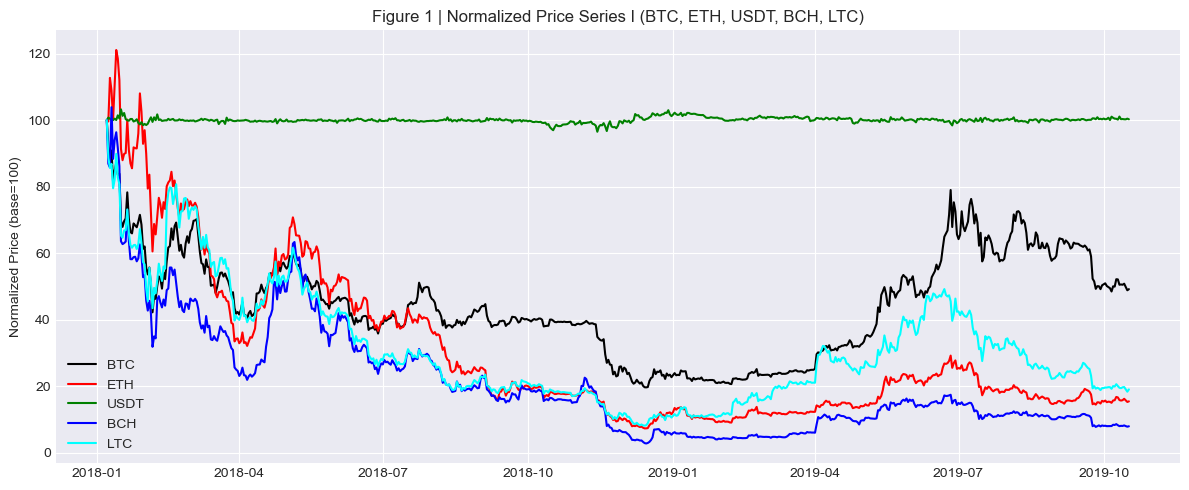

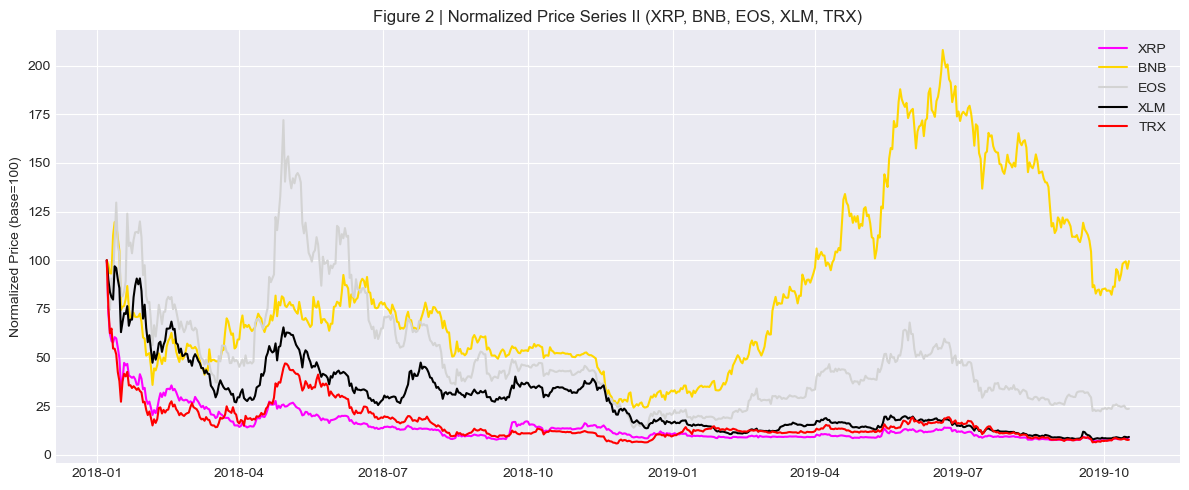

In [20]:
# --- Figure 1: BTC, ETH, USDT, BCH, LTC ---
assets_1  = ['BTC', 'ETH', 'USDT', 'BCH', 'LTC']
df_norm_1 = (df_prices.loc['2018-01-07':, assets_1] / df_prices.loc['2018-01-07', assets_1]) * 100
colors_1  = ['black', 'red', 'green', 'blue', 'cyan']

plt.figure(figsize=(12, 5))
for i, col in enumerate(df_norm_1.columns):
    plt.plot(df_norm_1.index, df_norm_1[col], label=col, color=colors_1[i])
plt.title('Figure 1 | Normalized Price Series I (BTC, ETH, USDT, BCH, LTC)')
plt.ylabel('Normalized Price (base=100)')
plt.legend()
plt.tight_layout()
plt.show()

# --- Figure 2: XRP, BNB, EOS, XLM, TRX ---
assets_2  = ['XRP', 'BNB', 'EOS', 'XLM', 'TRX']
df_norm_2 = (df_prices.loc['2018-01-07':, assets_2] / df_prices.loc['2018-01-07', assets_2]) * 100
colors_2  = ['magenta', 'gold', 'lightgrey', 'black', 'red']

plt.figure(figsize=(12, 5))
for i, col in enumerate(df_norm_2.columns):
    plt.plot(df_norm_2.index, df_norm_2[col], label=col, color=colors_2[i])
plt.title('Figure 2 | Normalized Price Series II (XRP, BNB, EOS, XLM, TRX)')
plt.ylabel('Normalized Price (base=100)')
plt.legend()
plt.tight_layout()
plt.show()

---
## Sel 5 — Visualisasi Minimum Spanning Tree (Figure 3 & 4)

Mereplikasi Figure 3 dari paper acuan: struktur jaringan MST aset kripto selama periode **gelembung spekulatif** (Sep 2017 – Jan 2018) dan periode **stabil** (Jun 2019 – Okt 2019).

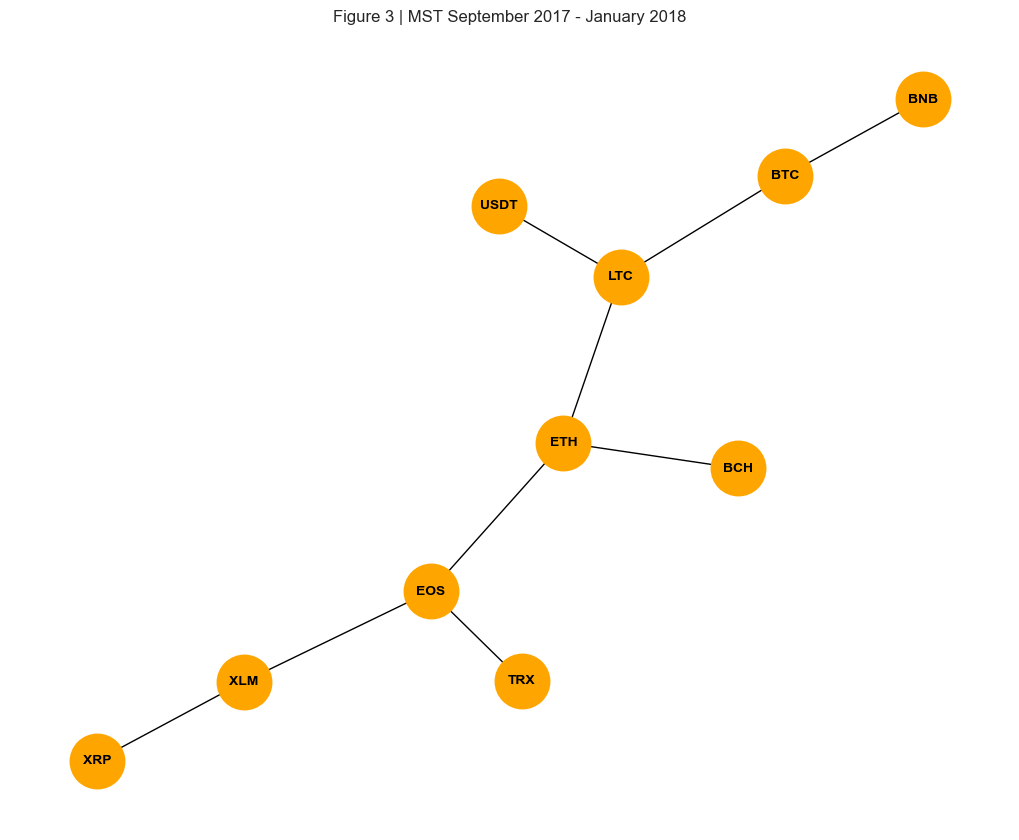

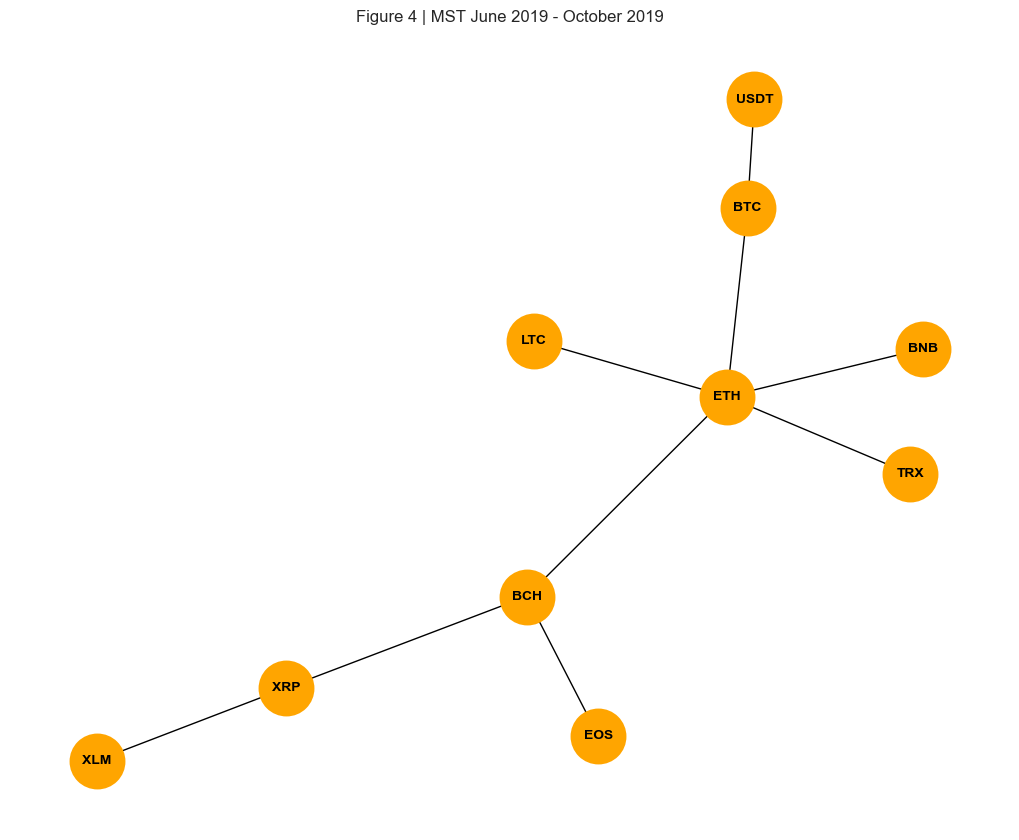

In [21]:
# --- Figure 3 | MST September 2017 - January 2018 ---
df_bubble   = df_returns.loc['2017-09-14':'2018-01-31']
corr_bubble = df_bubble.corr()
dist_bubble = np.sqrt(2 * (1 - corr_bubble))

G          = nx.from_pandas_adjacency(dist_bubble)
mst_bubble = nx.minimum_spanning_tree(G, weight='weight')

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(mst_bubble, seed=42)
nx.draw(mst_bubble, pos, with_labels=True, node_color='orange',
        node_size=1500, edge_color='black', linewidths=1.5,
        font_size=10, font_weight='bold')
plt.title('Figure 3 | MST September 2017 - January 2018', fontsize=12)
plt.tight_layout()
plt.show()

# --- Figure 4 | MST June 2019 - October 2019 ---
df_stable   = df_returns.loc['2019-06-01':'2019-10-17']
corr_stable = df_stable.corr()
dist_stable = np.sqrt(2 * (1 - corr_stable))

G2         = nx.from_pandas_adjacency(dist_stable)
mst_stable = nx.minimum_spanning_tree(G2, weight='weight')

plt.figure(figsize=(10, 8))
pos2 = nx.spring_layout(mst_stable, seed=42)
nx.draw(mst_stable, pos2, with_labels=True, node_color='orange',
        node_size=1500, edge_color='black', linewidths=1.5,
        font_size=10, font_weight='bold')
plt.title('Figure 4 | MST June 2019 - October 2019', fontsize=12)
plt.tight_layout()
plt.show()

---
## Sel 6 — Fungsi Pembantu (Helper Functions)

Implementasi:
- **RMT Filter** — Penyaringan noise matriks korelasi via *Random Matrix Theory* (Marcenko-Pastur)
- **MST Builder** — Konversi korelasi ke matriks jarak
- **Eigenvector Centrality** — Ukuran sentralitas node dalam jaringan
- **VaR, Max Drawdown, Rachev Ratio** — Metrik risiko

In [22]:
def apply_rmt_filter(returns_data):
    """Filter noise dari matriks korelasi menggunakan Random Matrix Theory."""
    if isinstance(returns_data, pd.DataFrame):
        data = returns_data.values
    else:
        data = returns_data
    T, N = data.shape
    Q    = T / N
    C    = np.corrcoef(data.T)

    eigenvalues, eigenvectors = eigh(C)
    eigenvalues  = eigenvalues[::-1]
    eigenvectors = eigenvectors[:, ::-1]

    # Marcenko-Pastur upper bound
    lambda_plus      = 1 + (1/Q) + 2*np.sqrt(1/Q)
    significant_mask = eigenvalues > lambda_plus
    Lambda_filtered  = np.diag(np.where(significant_mask, eigenvalues, 0))
    C_filtered       = eigenvectors @ Lambda_filtered @ eigenvectors.T
    return C_filtered


def build_mst(correlation_matrix):
    """Konversi matriks korelasi ke matriks jarak untuk MST."""
    distance_matrix = np.sqrt(2 - 2*correlation_matrix)
    np.fill_diagonal(distance_matrix, 0)
    return distance_matrix


def compute_eigenvector_centrality(distance_matrix):
    """Hitung sentralitas eigenvector dari matriks jarak."""
    adjacency = 1 / (distance_matrix + 1e-8)
    np.fill_diagonal(adjacency, 0)
    eigenvalues, eigenvectors = eigh(adjacency)
    principal_eigenvector = np.abs(eigenvectors[:, -1])
    centrality = principal_eigenvector / principal_eigenvector.sum()
    return centrality


def calculate_var(returns, confidence=0.95):
    """Value at Risk pada tingkat kepercayaan tertentu."""
    return np.percentile(returns, (1 - confidence) * 100)


def calculate_rachev_ratio(returns, alpha=0.10):
    """Rachev Ratio = CVaR_upper / CVaR_lower pada alpha tertentu."""
    threshold_upper = np.percentile(returns, (1 - alpha) * 100)
    threshold_lower = np.percentile(returns, alpha * 100)
    cvar_upper = returns[returns >= threshold_upper].mean()
    cvar_lower = abs(returns[returns <= threshold_lower].mean())
    return cvar_upper / cvar_lower if cvar_lower > 0 else 0


def calculate_max_drawdown(cumulative_returns):
    """Maximum Drawdown dari seri cumulative returns."""
    running_max = np.maximum.accumulate(cumulative_returns)
    drawdown    = (cumulative_returns - running_max) / running_max
    return drawdown.min()


print("Helper functions defined successfully!")

Helper functions defined successfully!


---
## Sel New — Analisis Dinamika MST (Figure 5)

Analisis *rolling window* untuk menghitung ambang batas MST (*max link distance*) dan koefisien *residuality* sepanjang waktu.

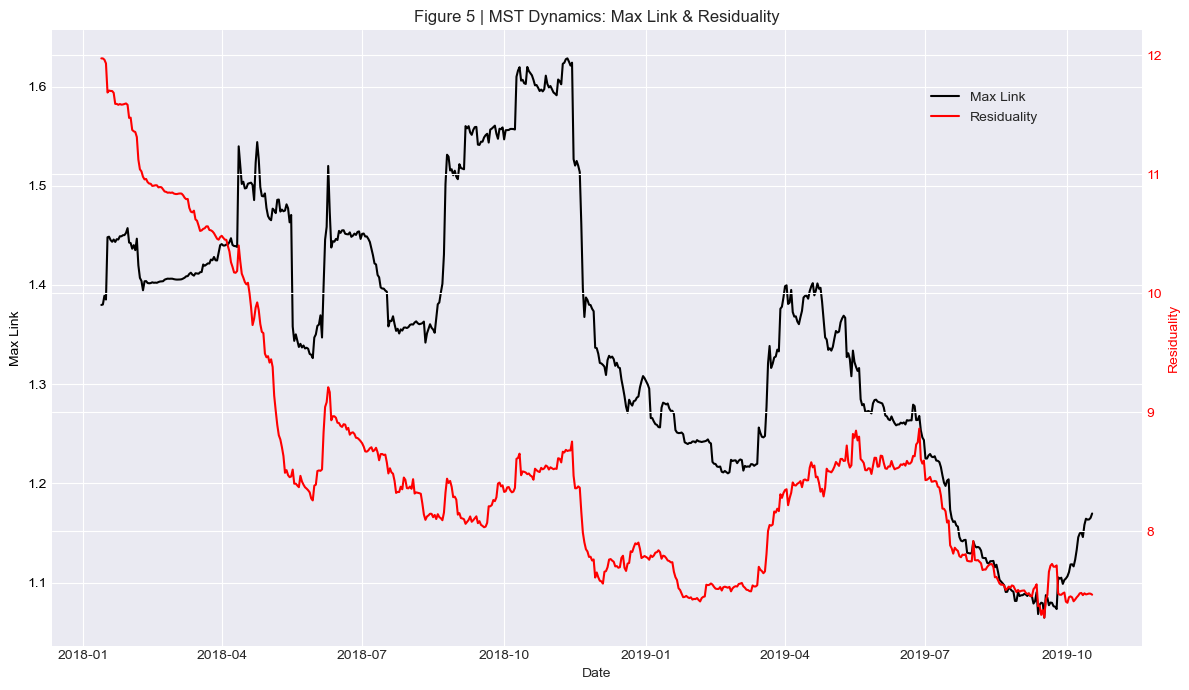

In [23]:
def calculate_rolling_mst_metrics(returns_df, window=120):
    """Hitung dinamika MST dengan rolling window."""
    dates         = returns_df.index[window:]
    max_links     = []
    residualities = []

    for i in range(window, len(returns_df)):
        window_data  = returns_df.iloc[i - window:i]
        corr_f       = apply_rmt_filter(window_data)
        mst_weights  = build_mst(corr_f)
        max_links.append(np.max(mst_weights))
        residualities.append(np.sum(mst_weights) / (returns_df.shape[1] - 1))

    return pd.DataFrame(
        {'Max Link': max_links, 'Residuality': residualities},
        index=dates
    )


mst_dyn = calculate_rolling_mst_metrics(df_returns)

# Visualisasi dengan dual axis
fig, ax1 = plt.subplots(figsize=(12, 7))
ax1.set_xlabel('Date')
ax1.set_ylabel('Max Link', color='black')
ax1.plot(mst_dyn.index, mst_dyn['Max Link'], color='black', label='Max Link')
ax1.tick_params(axis='y', labelcolor='black')

ax2 = ax1.twinx()
ax2.set_ylabel('Residuality', color='red')
ax2.plot(mst_dyn.index, mst_dyn['Residuality'], color='red', label='Residuality')
ax2.tick_params(axis='y', labelcolor='red')

fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88))
plt.title('Figure 5 | MST Dynamics: Max Link & Residuality')
plt.tight_layout()
plt.show()

---
## Sel 7 — Implementasi Strategi Portofolio

Setiap strategi diimplementasikan sebagai kelas yang mewarisi `PortfolioStrategy`.

**AGGP v2** menerapkan 4 perbaikan kunci:
1. **[Fix 1]** Sensor *average partial correlation* dari matriks presisi Glasso (lebih sensitif)
2. **[Fix 2]** Logika gamma dibalik — defensif saat korelasi tinggi (pasar stres)
3. **[Fix 3]** `w_net` menggunakan NW γ=1.0 (best performer Giudici et al.)
4. **[Fix 4]** Fallback aman ke EW jika optimizer gagal

In [24]:
# ── Base Class ────────────────────────────────────────────────────────────────
class PortfolioStrategy:
    def __init__(self, name):
        self.name            = name
        self.weights_history = []
        self.returns_history = []

    def get_weights(self, returns_data):
        raise NotImplementedError


# ── 1. Equally Weighted ───────────────────────────────────────────────────────
class EquallyWeighted(PortfolioStrategy):
    def get_weights(self, returns_data):
        n = returns_data.shape[1]
        return np.ones(n) / n


# ── 2. Classical Markowitz ────────────────────────────────────────────────────
class ClassicalMarkowitz(PortfolioStrategy):
    """Optimasi Mean-Variance tradisional (minimasi varians portofolio)."""
    def get_weights(self, returns_data):
        n  = returns_data.shape[1]
        mu = returns_data.mean().values
        S  = returns_data.cov().values

        objective   = lambda w: w @ S @ w
        constraints = [
            {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w @ mu - mu.mean()}
        ]
        res = minimize(objective, np.ones(n) / n,
                       method='SLSQP', bounds=[(0, 1)] * n,
                       constraints=constraints)
        return res.x if res.success else np.ones(n) / n


# ── 3. Glasso Markowitz ───────────────────────────────────────────────────────
class GlassoMarkowitz(PortfolioStrategy):
    """Markowitz dengan matriks kovarians diestimasi via Graphical Lasso."""
    def get_weights(self, returns_data):
        n  = returns_data.shape[1]
        mu = returns_data.mean().values
        try:
            glasso = GraphicalLassoCV()
            glasso.fit(returns_data.values)
            S = glasso.covariance_
        except Exception:
            S = returns_data.cov().values

        objective   = lambda w: w @ S @ w
        constraints = [
            {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w @ mu - mu.mean()}
        ]
        res = minimize(objective, np.ones(n) / n,
                       method='SLSQP', bounds=[(0, 1)] * n,
                       constraints=constraints)
        return res.x if res.success else np.ones(n) / n


# ── 4. Network Markowitz ──────────────────────────────────────────────────────
class NetworkMarkowitz(PortfolioStrategy):
    """Network Markowitz: RMT + MST + penalti sentralitas eigenvector."""
    def __init__(self, name="Network Markowitz", gamma=0):
        super().__init__(name)
        self.gamma = gamma

    def get_weights(self, returns_data):
        n   = returns_data.shape[1]
        mu  = returns_data.mean().values
        sig = returns_data.std().values

        Cf   = apply_rmt_filter(returns_data)
        dist = build_mst(Cf)
        cent = compute_eigenvector_centrality(dist)
        Sf   = np.outer(sig, sig) * Cf

        objective   = lambda w: w @ Sf @ w + self.gamma * np.sum(cent * w)
        constraints = [
            {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w @ mu - mu.mean()}
        ]
        res = minimize(objective, np.ones(n) / n,
                       method='SLSQP', bounds=[(0, 1)] * n,
                       constraints=constraints)
        return res.x if res.success else np.ones(n) / n


# ── 5. Adaptive Graph-Gated Portfolio (AGGP v2) ───────────────────────────────
class AdaptiveGraphPortfolio(PortfolioStrategy):
    """
    AGGP v2: Menggunakan rata-rata korelasi parsial (avg_corr) dari matriks
    presisi Graphical Lasso sebagai sensor kondisi pasar yang adaptif.

    Mekanisme adaptasi gamma_t:
      - avg_corr TINGGI (pasar stres) -> gamma_t KECIL -> lebih ke Markowitz (defensif)
      - avg_corr RENDAH (pasar normal) -> gamma_t BESAR -> lebih ke Network Markowitz (agresif)

    Blending: w = (1 - gamma_t) * w_markowitz + gamma_t * w_network
    """
    def __init__(self, name="AGGP (Optimized)", sensitivity=1.5):
        super().__init__(name)
        self.sensitivity = sensitivity

    def get_weights(self, returns_data):
        n   = returns_data.shape[1]
        mu  = returns_data.mean().values
        sig = returns_data.std().values

        # --- Estimasi kovarians & presisi via Graphical Lasso ---
        try:
            glasso = GraphicalLassoCV(cv=5)
            glasso.fit(returns_data.values)
            Sf = glasso.covariance_
            Pf = glasso.precision_
        except Exception:
            Cf = apply_rmt_filter(returns_data)
            Sf = np.outer(sig, sig) * Cf
            Pf = Cf

        # --- FIX 1: Sensor avg_corr dari matriks presisi ---
        mask     = ~np.eye(n, dtype=bool)
        avg_corr = np.mean(np.abs(Pf[mask]))

        # --- FIX 2: Logika gamma dibalik (defensif saat korelasi tinggi) ---
        gamma_t = np.clip(1.0 - avg_corr * self.sensitivity, 0.1, 0.9)

        # --- FIX 3: w_net = Network Markowitz gamma=1.0 ---
        Cf_rmt = apply_rmt_filter(returns_data)
        dist   = build_mst(Cf_rmt)
        cent   = compute_eigenvector_centrality(dist)
        Sf_nw  = np.outer(sig, sig) * Cf_rmt

        obj_nw  = lambda w: w @ Sf_nw @ w + 1.0 * np.sum(cent * w)
        cons_nw = [
            {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w @ mu - mu.mean()}
        ]
        res_nw = minimize(obj_nw, np.ones(n) / n, method='SLSQP',
                          bounds=[(0, 1)] * n, constraints=cons_nw)
        w_net = res_nw.x if res_nw.success else np.ones(n) / n  # FIX 4

        # --- FIX 4: Markowitz GMV dengan return constraint & fallback aman ---
        obj_mko  = lambda w: w @ Sf @ w
        cons_mko = [
            {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w @ mu - mu.mean()}
        ]
        res_mko = minimize(obj_mko, np.ones(n) / n, method='SLSQP',
                           bounds=[(0, 1)] * n, constraints=cons_mko)
        w_mko = res_mko.x if res_mko.success else np.ones(n) / n

        # --- Blending adaptif ---
        return (1 - gamma_t) * w_mko + gamma_t * w_net


print("All portfolio strategy classes defined successfully!")

All portfolio strategy classes defined successfully!


---
## Sel 8 — Framework Backtesting

Sistem pengujian menggunakan *rolling window* dengan:
- `window_size = 120` hari training
- `rebalance_freq = 7` hari (mingguan)
- `transaction_cost = 0.1%` (10 basis points)

In [25]:
def backtest_strategy(strategy, df_returns, window_size=120,
                      rebalance_freq=7, transaction_cost=0.001):
    """
    Simulasi backtest dengan rolling window.

    Parameters
    ----------
    strategy         : PortfolioStrategy instance
    df_returns       : pd.DataFrame — daily returns
    window_size      : int — ukuran jendela training (hari)
    rebalance_freq   : int — frekuensi rebalancing (hari)
    transaction_cost : float — biaya transaksi per rebalancing

    Returns
    -------
    dict dengan 'strategy', 'returns', 'cumulative_returns', 'results_df'
    """
    portfolio_returns = []
    dates             = []

    for i in range(window_size, len(df_returns), rebalance_freq):
        train    = df_returns.iloc[i - window_size:i]
        w        = strategy.get_weights(train)
        test_end  = min(i + rebalance_freq, len(df_returns))
        test_data = df_returns.iloc[i:test_end]

        for j in range(len(test_data)):
            daily_ret = np.dot(w, test_data.iloc[j].values)
            if j == 0 and len(portfolio_returns) > 0:
                daily_ret -= transaction_cost
            portfolio_returns.append(daily_ret)
            dates.append(test_data.index[j])

    res_df = pd.DataFrame({'date': dates, 'return': portfolio_returns})
    res_df['cumulative_return'] = (1 + res_df['return']).cumprod()

    return {
        'strategy':           strategy.name,
        'returns':            np.array(portfolio_returns),
        'cumulative_returns': res_df['cumulative_return'].values,
        'results_df':         res_df
    }


print("Backtest framework defined successfully!")

Backtest framework defined successfully!


---
## Sel 9 — Eksekusi Backtesting

Menjalankan simulasi backtest untuk semua strategi. **Perhatian:** proses ini bisa memakan waktu beberapa menit karena AGGP menjalankan Graphical Lasso di setiap rebalancing.

In [26]:
# --- Inisialisasi strategi ---
gamma_values = [1.0]  # Best performer dari Giudici et al. (2020)

strategies = [
    EquallyWeighted("EW"),
    ClassicalMarkowitz("CM"),
    GlassoMarkowitz("GM"),
    NetworkMarkowitz("NW (gamma=0)", gamma=0),
] + [
    NetworkMarkowitz(f"NW (gamma={g})", gamma=g) for g in gamma_values
] + [
    AdaptiveGraphPortfolio("AGGP (Optimized)", sensitivity=2.0)
]

# --- Eksekusi backtest ---
results = {}
for strat in strategies:
    print(f"Backtesting: {strat.name}...")
    results[strat.name] = backtest_strategy(strat, df_returns)
    print(f"  -> Done. Final cumulative return: "
          f"{(results[strat.name]['cumulative_returns'][-1] - 1) * 100:.2f}%")

print("\nAll backtests completed!")

Backtesting: EW...
  -> Done. Final cumulative return: -88.49%
Backtesting: CM...
  -> Done. Final cumulative return: -61.56%
Backtesting: GM...
  -> Done. Final cumulative return: -67.05%
Backtesting: NW (gamma=0)...
  -> Done. Final cumulative return: -67.56%
Backtesting: NW (gamma=1.0)...
  -> Done. Final cumulative return: -48.16%
Backtesting: AGGP (Optimized)...
  -> Done. Final cumulative return: -65.37%

All backtests completed!


---
## Sel 10 — Analisis Performa Periodik (TABLE 2)

Tabel perbandingan *cumulative P&L* yang disampel setiap 4 bulan (Januari, Mei, September) — mereplikasi format Tabel 2 pada paper acuan.

In [27]:
target_dates = [
    '2018-01-31', '2018-05-31', '2018-09-30',
    '2019-01-31', '2019-05-31', '2019-09-30'
]

table2_rows = []
for strat_name, res in results.items():
    df_res = res['results_df'].set_index('date')
    row    = {'Strategy': strat_name}
    for td in target_dates:
        idx     = df_res.index.searchsorted(pd.Timestamp(td))
        idx     = min(idx, len(df_res) - 1)
        cum_ret = (df_res['cumulative_return'].iloc[idx] - 1) * 100
        row[td] = round(cum_ret, 2)
    table2_rows.append(row)

table2 = pd.DataFrame(table2_rows).set_index('Strategy')
table2.columns = ['Jan-2018', 'May-2018', 'Sep-2018', 'Jan-2019', 'May-2019', 'Sep-2019']

print("TABLE 2 | Cumulative Profits and Losses (%)")
print(table2.to_string())

TABLE 2 | Cumulative Profits and Losses (%)
                  Jan-2018  May-2018  Sep-2018  Jan-2019  May-2019  Sep-2019
Strategy                                                                    
EW                  -35.53    -58.96    -77.02    -89.67    -77.88    -88.82
CM                  -34.32    -57.88    -59.66    -68.22    -55.67    -62.16
GM                  -33.86    -60.11    -61.90    -73.12    -62.49    -67.53
NW (gamma=0)        -41.59    -62.30    -63.81    -71.79    -61.83    -68.05
NW (gamma=1.0)      -39.09    -51.94    -53.57    -54.17    -41.10    -48.05
AGGP (Optimized)    -34.33    -59.27    -61.05    -71.55    -60.60    -65.82


---
## Sel 11 — Visualisasi Performa Kumulatif (FIGURE 6)

Evolusi nilai portofolio dengan asumsi investasi awal **100 USD** — periode 7 Januari 2018 – 17 Oktober 2019.

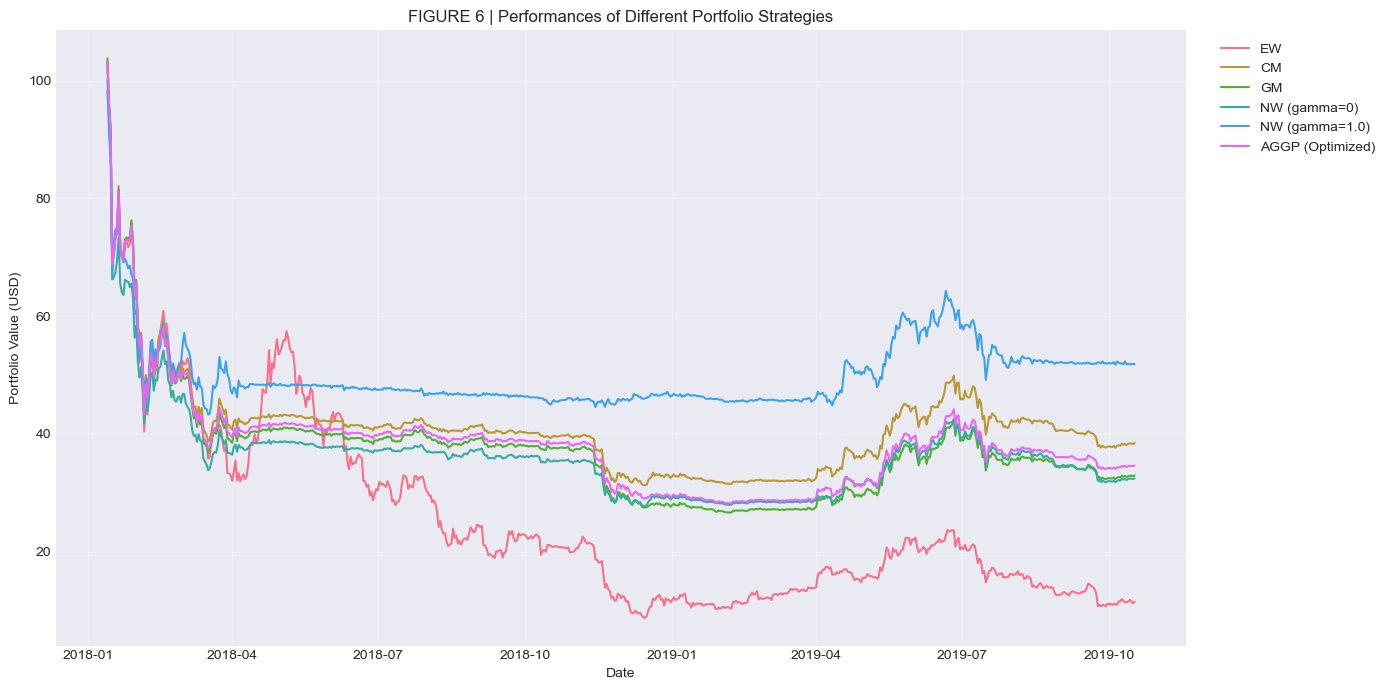

Figure saved as 'cumulative_returns.png'


In [28]:
plt.figure(figsize=(14, 7))

for name, res in results.items():
    # Skala cumulative_returns (basis 1.0) ke 100 USD
    plt.plot(
        res['results_df']['date'],
        res['cumulative_returns'] * 100,
        label=name
    )

plt.title('FIGURE 6 | Performances of Different Portfolio Strategies')
plt.xlabel('Date')
plt.ylabel('Portfolio Value (USD)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cumulative_returns.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as 'cumulative_returns.png'")

---
## Sel 12 — Analisis Risiko Periodik (TABLE 3 — VaR 95%)

*Value at Risk* pada tingkat kepercayaan 95% untuk jendela 4 bulan. Nilai disajikan sebagai nilai absolut × 100 (sesuai paper acuan).

In [29]:
# Definisi jendela 4 bulan untuk sampling VaR
var_windows = [
    ('Jan-2018', '2017-09-01', '2018-01-31'),
    ('May-2018', '2018-01-01', '2018-05-31'),
    ('Sep-2018', '2018-05-01', '2018-09-30'),
    ('Jan-2019', '2018-09-01', '2019-01-31'),
    ('May-2019', '2019-01-01', '2019-05-31'),
    ('Sep-2019', '2019-05-01', '2019-09-30'),
]

table3_rows = []
for strat_name, res in results.items():
    df_res = res['results_df'].set_index('date')
    row    = {'Strategy': strat_name}
    for label, start, end in var_windows:
        segment = df_res.loc[start:end, 'return'].values
        if len(segment) > 0:
            v = abs(calculate_var(segment, 0.95)) * 100
        else:
            v = np.nan
        row[label] = round(v, 4)
    table3_rows.append(row)

table3 = pd.DataFrame(table3_rows).set_index('Strategy')

print("TABLE 3 | VaR 95% (absolute × 100)")
print(table3.to_string())

TABLE 3 | VaR 95% (absolute × 100)
                  Jan-2018  May-2018  Sep-2018  Jan-2019  May-2019  Sep-2019
Strategy                                                                    
EW                 13.7904   10.5313    6.7177    9.2504    4.1651    6.5851
CM                 12.8261    7.0331    0.9465    1.6616    1.3081    3.2604
GM                 13.4648    7.2588    1.1750    2.1097    1.6533    3.4798
NW (gamma=0)       12.4709    6.2805    1.0063    1.7959    1.3018    3.0917
NW (gamma=1.0)     10.3486    6.5806    0.6633    0.8934    1.2449    2.9833
AGGP (Optimized)   13.1532    7.2255    1.0536    1.8694    1.6255    3.1667


---
## Sel 13 — Analisis Risk-Adjusted Return (TABLE 4 — Sharpe Ratio)

*Sharpe Ratio* periodik untuk jendela 4 bulan: `SR = Mean(returns) / Std(returns)`.

In [30]:
table4_rows = []
for strat_name, res in results.items():
    df_res = res['results_df'].set_index('date')
    row    = {'Strategy': strat_name}
    for label, start, end in var_windows:
        segment = df_res.loc[start:end, 'return'].values
        if len(segment) > 1:
            sr = np.mean(segment) / np.std(segment)
        else:
            sr = np.nan
        row[label] = round(sr, 4)
    table4_rows.append(row)

table4 = pd.DataFrame(table4_rows).set_index('Strategy')

print("TABLE 4 | Sharpe Ratio (4-month windows)")
print(table4.to_string())

TABLE 4 | Sharpe Ratio (4-month windows)
                  Jan-2018  May-2018  Sep-2018  Jan-2019  May-2019  Sep-2019
Strategy                                                                    
EW                 -0.2532   -0.0803   -0.1192   -0.1020    0.1432   -0.0356
CM                 -0.2508   -0.1290   -0.0758   -0.1458    0.1553    0.0240
GM                 -0.2355   -0.1286   -0.0696   -0.1771    0.1424    0.0382
NW (gamma=0)       -0.3442   -0.1557   -0.0723   -0.1471    0.1497    0.0145
NW (gamma=1.0)     -0.3849   -0.1169   -0.0623   -0.0227    0.1324    0.0189
AGGP (Optimized)   -0.2496   -0.1286   -0.0716   -0.1738    0.1441    0.0369


---
## Sel 14 — Analisis Tail-Risk (TABLE 5 — Rachev Ratio)

*Rachev Ratio* = CVaR_upper(10%) / CVaR_lower(10%). Memberikan wawasan tentang asimetri distribusi return pada ekor (*tails*), yang umum ditemukan di pasar kripto.

In [31]:
table5_rows = []
for strat_name, res in results.items():
    df_res = res['results_df'].set_index('date')
    row    = {'Strategy': strat_name}
    for label, start, end in var_windows:
        segment = df_res.loc[start:end, 'return'].values
        if len(segment) > 0:
            rr = calculate_rachev_ratio(segment, alpha=0.10)
        else:
            rr = np.nan
        row[label] = round(rr, 4)
    table5_rows.append(row)

table5 = pd.DataFrame(table5_rows).set_index('Strategy')

print("TABLE 5 | Rachev Ratio (alpha=10%, 4-month windows)")
print(table5.to_string())

TABLE 5 | Rachev Ratio (alpha=10%, 4-month windows)
                  Jan-2018  May-2018  Sep-2018  Jan-2019  May-2019  Sep-2019
Strategy                                                                    
EW                  0.3926    0.7528    0.7711    0.7686    1.4097    0.7674
CM                  0.3969    0.6104    0.7998    0.6568    1.9250    0.9866
GM                  0.4126    0.6191    0.7862    0.5687    1.6922    0.9800
NW (gamma=0)        0.2494    0.5624    0.8007    0.6417    2.0024    1.0098
NW (gamma=1.0)      0.3488    0.7728    0.8245    0.9999    2.0640    1.0875
AGGP (Optimized)    0.3867    0.6176    0.7908    0.5827    1.7264    0.9977


---
## Sel 15 — Analisis Fase Pasar (TABLE 6)

Pemetaan performa ke tiga fase utama:
- **Bearish**: Januari 2018 – Maret 2019
- **Recovery**: April 2019 – Juni 2019
- **Stable/Sideways**: Juli 2019 – Oktober 2019

**Hipotesis AGGP v2 sebagai *All-Terrain Model*:**
- *Bearish* → `avg_corr` tinggi → `gamma_t` kecil → lebih ke Markowitz (defensif)
- *Recovery/Stable* → `avg_corr` rendah → `gamma_t` besar → lebih ke NW γ=1.0 (agresif)

In [32]:
# Definisi Fase Pasar
fase_pasar = {
    'Bearish':   ('2018-01-01', '2019-03-31'),
    'Recovery':  ('2019-04-01', '2019-06-30'),
    'Stable':    ('2019-07-01', '2019-10-17')
}

# --- Panel A: Sharpe Ratio per fase ---
sharpe_rows = []
for strat_name, res in results.items():
    df_res = res['results_df'].set_index('date')
    row    = {'Strategy': strat_name}
    for fase, (start, end) in fase_pasar.items():
        segment = df_res.loc[start:end, 'return'].values
        sr      = np.mean(segment) / np.std(segment) if len(segment) > 1 else np.nan
        row[fase] = round(sr, 4)
    sharpe_rows.append(row)

sharpe_df = pd.DataFrame(sharpe_rows).set_index('Strategy')

# --- Panel B: Rachev Ratio per fase ---
rachev_rows = []
for strat_name, res in results.items():
    df_res = res['results_df'].set_index('date')
    row    = {'Strategy': strat_name}
    for fase, (start, end) in fase_pasar.items():
        segment = df_res.loc[start:end, 'return'].values
        rr      = calculate_rachev_ratio(segment, alpha=0.10) if len(segment) > 0 else np.nan
        row[fase] = round(rr, 4)
    rachev_rows.append(row)

rachev_df = pd.DataFrame(rachev_rows).set_index('Strategy')

print("TABLE 6 | Market Phase Performance")
print("\nPanel A: Sharpe Ratio")
print(sharpe_df.to_string())
print("\nPanel B: Rachev Ratio (alpha=10%)")
print(rachev_df.to_string())

TABLE 6 | Market Phase Performance

Panel A: Sharpe Ratio
                  Bearish  Recovery  Stable
Strategy                                   
EW                -0.0726    0.1286 -0.1301
CM                -0.0923    0.1844 -0.1022
GM                -0.0991    0.1732 -0.0950
NW (gamma=0)      -0.1072    0.1763 -0.1095
NW (gamma=1.0)    -0.0685    0.1359 -0.0628
AGGP (Optimized)  -0.0975    0.1726 -0.0929

Panel B: Rachev Ratio (alpha=10%)
                  Bearish  Recovery  Stable
Strategy                                   
EW                 0.7933    1.2168  0.5712
CM                 0.6463    1.2463  0.7523
GM                 0.6275    1.1627  0.7477
NW (gamma=0)       0.5982    1.2883  0.7615
NW (gamma=1.0)     0.7244    1.4069  0.8656
AGGP (Optimized)   0.6344    1.1755  0.7653


---
## Ringkasan Hasil

Cell ini mencetak ringkasan akhir performa semua strategi.

In [33]:
print("=" * 60)
print("RINGKASAN PERFORMA STRATEGI (Full Period)")
print("=" * 60)

summary_rows = []
for strat_name, res in results.items():
    rets = res['returns']
    cum  = res['cumulative_returns']
    summary_rows.append({
        'Strategy':          strat_name,
        'Total Return (%)':  round((cum[-1] - 1) * 100, 2),
        'Ann. Sharpe':       round(np.mean(rets) / np.std(rets) * np.sqrt(252), 4),
        'Max Drawdown (%)':  round(calculate_max_drawdown(cum) * 100, 2),
        'VaR 95% (×100)':    round(abs(calculate_var(rets, 0.95)) * 100, 4),
        'Rachev (α=10%)':    round(calculate_rachev_ratio(rets, 0.10), 4)
    })

summary_df = pd.DataFrame(summary_rows).set_index('Strategy')
print(summary_df.to_string())

RINGKASAN PERFORMA STRATEGI (Full Period)
                  Total Return (%)  Ann. Sharpe  Max Drawdown (%)  VaR 95% (×100)  Rachev (α=10%)
Strategy                                                                                         
EW                          -88.49      -0.8646            -91.45          7.7519          0.8014
CM                          -61.56      -0.8464            -69.50          3.6092          0.7734
GM                          -67.05      -0.9317            -74.31          4.2237          0.7402
NW (gamma=0)                -67.56      -1.0727            -72.30          3.1887          0.7487
NW (gamma=1.0)              -48.16      -0.6127            -55.97          2.7660          0.8831
AGGP (Optimized)            -65.37      -0.9144            -72.66          3.9677          0.7515
